# RunGap Corridor Environment Visualization

This notebook demonstrates the RunGap corridor environment with:
1. Arena rendering (overview of the gap corridor)
2. Zero-action rollout with reward/position plots
3. Video from `close_profile-rodent` camera
4. Egocentric vision output from mujoco_warp VisionRenderer
5. Concatenated video with vision overlay in upper-left corner

In [1]:
%load_ext autoreload
%autoreload 2

import os
import sys

os.environ["MUJOCO_GL"] = "egl"
os.environ["PYOPENGL_PLATFORM"] = "egl"
os.environ["XLA_PYTHON_CLIENT_PREALLOCATE"] = "false"

In [2]:
import jax
import jax.numpy as jp
import matplotlib.pyplot as plt
import mediapy as media
import mujoco
import numpy as np
from tqdm import tqdm

from vnl_playground.tasks.rodent import run_gap

## 1. Initialize Environment and Render Arena

In [3]:
env = run_gap.RunGap()
mj_model = env.mj_model
fps = int(1.0 / env.dt)

print(f"Action size: {env.action_size}")
print(f"Obs size: {env.observation_size}")
print(f"Corridor end: {env._corridor_end_x:.2f}m")
print(f"Num platforms: {len(env._platform_positions)}")
print(f"FPS: {fps}")
print(f"Cameras: {[mj_model.camera(i).name for i in range(mj_model.ncam)]}")

Warp 1.11.0 initialized:
   CUDA Toolkit 12.9, Driver 13.1
   Devices:
     "cpu"      : "x86_64"
     "cuda:0"   : "NVIDIA RTX A5000" (24 GiB, sm_86, mempool enabled)
   Kernel cache:
     /home/talmolab/.cache/warp/1.11.0
Warp DeprecationWarning: The symbol `warp.types.warp_type_to_np_dtype` will soon be removed from the public API. It can still be accessed from `warp._src.types.warp_type_to_np_dtype` but might be changed or removed without notice.
Warp DeprecationWarning: The symbol `warp.types.array` will soon be removed from the public API. Use `warp.array` instead.
Action size: 38
Module mujoco.mjx.third_party.mujoco_warp._src.smooth e142b0f load on device 'cuda:0' took 8.95 ms  (cached)
Module mujoco.mjx.third_party.mujoco_warp._src.collision_driver de6dc98 load on device 'cuda:0' took 0.58 ms  (cached)
Module _nxn_broadphase__locals__kernel_8c837afb 8c837af load on device 'cuda:0' took 1.07 ms  (cached)
Module ccd_kernel_builder__locals__ccd_kernel_d1f81bc0 d1f81bc load on devi

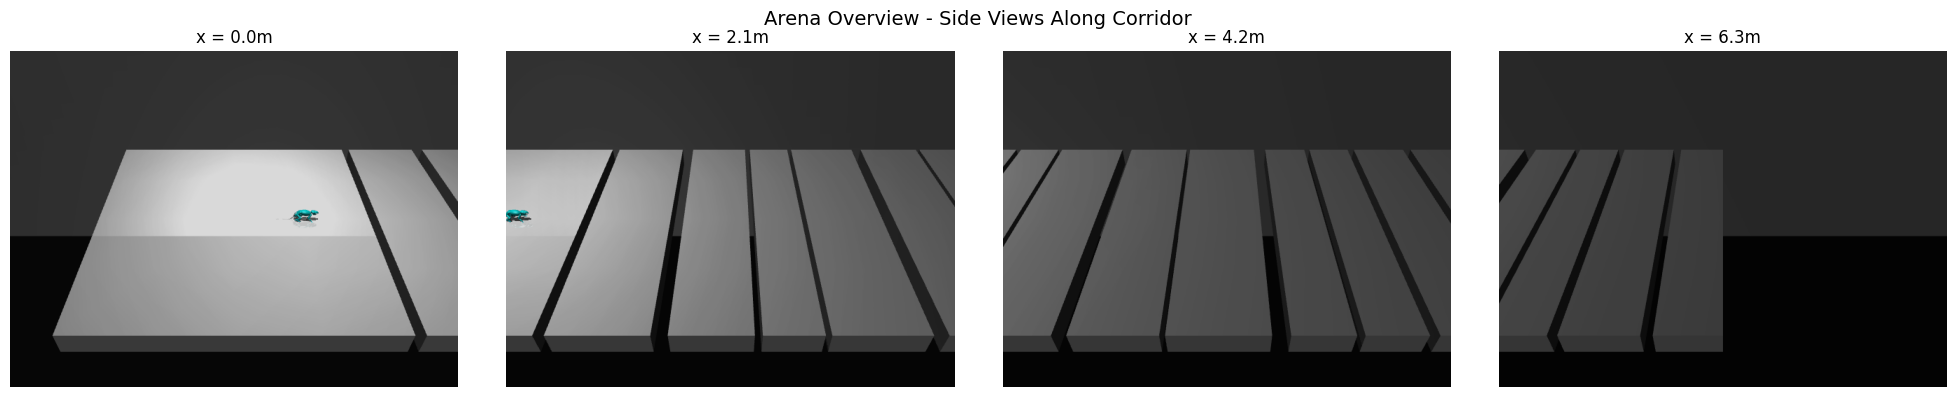

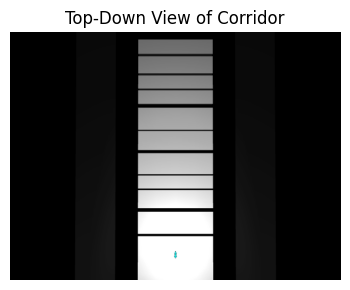

In [4]:
# Render a few static views of the arena
mj_data = mujoco.MjData(mj_model)
mujoco.mj_forward(mj_model, mj_data)

renderer = mujoco.Renderer(mj_model, height=480, width=640)

# Overview camera positions along the corridor
cam = mujoco.MjvCamera()
cam.type = mujoco.mjtCamera.mjCAMERA_FREE
cam.distance = 3.0
cam.elevation = -40

positions = [
    0.0,
    env._corridor_end_x / 3,
    2 * env._corridor_end_x / 3,
    env._corridor_end_x,
]
fig, axes = plt.subplots(1, 4, figsize=(20, 4))
for ax, x_pos in zip(axes, positions):
    cam.azimuth = 90
    cam.lookat[:] = [x_pos, 0.0, 0.0]
    renderer.update_scene(mj_data, camera=cam)
    ax.imshow(renderer.render())
    ax.set_title(f"x = {x_pos:.1f}m")
    ax.axis("off")
plt.suptitle("Arena Overview - Side Views Along Corridor", fontsize=14)
plt.tight_layout()
plt.show()

# Top-down view of full corridor
cam.distance = 8.0
cam.elevation = -89
cam.azimuth = 0
cam.lookat[:] = [env._corridor_end_x / 2, 0.0, 0.0]
renderer.update_scene(mj_data, camera=cam)
fig, ax = plt.subplots(1, 1, figsize=(16, 3))
ax.imshow(renderer.render())
ax.set_title("Top-Down View of Corridor")
ax.axis("off")
plt.tight_layout()
plt.show()

renderer.close()

## 2. Zero-Action Rollout

In [5]:
rng = jax.random.PRNGKey(0)
state = jax.jit(env.reset)(rng)
step_fn = jax.jit(env.step)

n_steps = 500
rollout_states = []
qposes = [np.array(state.data.qpos)]
rewards = []
positions = []

torso = state.data.bind(env.mjx_model, env._spec.body("torso-rodent"))
positions.append(np.array(torso.xpos))

for i in tqdm(range(n_steps), desc="Zero-action rollout"):
    action = jp.zeros(env.action_size)
    state = step_fn(state, action)
    rollout_states.append(state)
    qposes.append(np.array(state.data.qpos))
    rewards.append(float(state.reward))
    torso = state.data.bind(env.mjx_model, env._spec.body("torso-rodent"))
    positions.append(np.array(torso.xpos))
    if state.done > 0.5:
        break

qposes = np.array(qposes)
rewards = np.array(rewards)
positions = np.array(positions)

print(f"Steps: {len(rewards)}")
print(f"Mean reward: {rewards.mean():.4f}")
print(f"Final x-pos: {positions[-1, 0]:.4f}m")

E0211 09:58:43.231815  895122 slow_operation_alarm.cc:73] Constant folding an instruction is taking > 1s:

  %reduce_sum.7 = s32[] reduce(%constant.51, %constant.140), dimensions={0}, to_apply=%region_0.4, metadata={op_name="jit(reset)/reduce_sum" stack_frame_id=83}

This isn't necessarily a bug; constant-folding is inherently a trade-off between compilation time and speed at runtime. XLA has some guards that attempt to keep constant folding from taking too long, but fundamentally you'll always be able to come up with an input program that takes a long time.

If you'd like to file a bug, run with envvar XLA_FLAGS=--xla_dump_to=/tmp/foo and attach the results.
E0211 09:58:47.546112  893928 slow_operation_alarm.cc:140] The operation took 5.31437103s
Constant folding an instruction is taking > 1s:

  %reduce_sum.7 = s32[] reduce(%constant.51, %constant.140), dimensions={0}, to_apply=%region_0.4, metadata={op_name="jit(reset)/reduce_sum" stack_frame_id=83}

This isn't necessarily a bug; co

Module mujoco.mjx.warp.ffi edde159 load on device 'cuda:0' took 1.00 ms  (cached)


Zero-action rollout: 100%|██████████| 500/500 [00:35<00:00, 13.95it/s]

Steps: 500
Mean reward: 0.1028
Final x-pos: 0.5309m


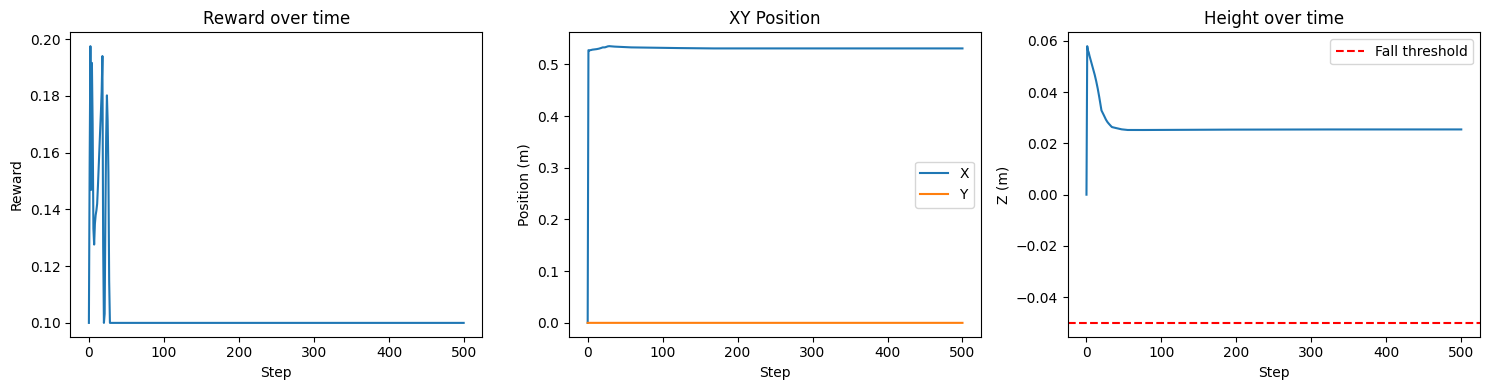

In [6]:
fig, axes = plt.subplots(1, 3, figsize=(15, 4))

axes[0].plot(rewards)
axes[0].set_xlabel("Step")
axes[0].set_ylabel("Reward")
axes[0].set_title("Reward over time")

axes[1].plot(positions[:, 0], label="X")
axes[1].plot(positions[:, 1], label="Y")
axes[1].set_xlabel("Step")
axes[1].set_ylabel("Position (m)")
axes[1].set_title("XY Position")
axes[1].legend()

axes[2].plot(positions[:, 2])
axes[2].axhline(y=-0.05, color="r", linestyle="--", label="Fall threshold")
axes[2].set_xlabel("Step")
axes[2].set_ylabel("Z (m)")
axes[2].set_title("Height over time")
axes[2].legend()

plt.tight_layout()
plt.show()

## 3. Video from close_profile-rodent Camera

In [7]:
mj_data = mujoco.MjData(mj_model)
renderer = mujoco.Renderer(mj_model, height=480, width=640)

render_every = 2
frames_profile = []
for qpos in tqdm(qposes[::render_every], desc="Rendering close_profile"):
    mj_data.qpos = qpos
    mujoco.mj_forward(mj_model, mj_data)
    renderer.update_scene(mj_data, camera="close_profile-rodent")
    frames_profile.append(renderer.render().copy())

renderer.close()
print(f"Rendered {len(frames_profile)} frames")
media.show_video(frames_profile, fps=fps // render_every)

Rendering close_profile: 100%|██████████| 251/251 [00:00<00:00, 368.02it/s]


Rendered 251 frames


This browser does not support the video tag.


## 4. Egocentric Vision Output (mujoco_warp VisionRenderer)

This uses the GPU-accelerated mujoco_warp batch renderer to produce 64x64 egocentric camera images.

In [8]:
# Patch mujoco_warp import for standalone renderer
_STANDALONE_MJW_PATH = os.path.join(
    os.path.dirname(os.path.dirname(os.getcwd())),
    "mujoco_warp",
)
if os.path.isdir(_STANDALONE_MJW_PATH):
    sys.modules.pop("mujoco_warp", None)
    if _STANDALONE_MJW_PATH not in sys.path:
        sys.path.insert(0, _STANDALONE_MJW_PATH)

import mujoco_warp
import mujoco_warp._src.io as _mjw_io

if not hasattr(mujoco.MjModel, "flexedge_J_rownnz"):
    _mjw_io.BLEEDING_EDGE_MUJOCO = False
    print(f"Patched BLEEDING_EDGE_MUJOCO=False (mujoco {mujoco.__version__})")

from vnl_playground.tasks.rodent.vision import VisionRenderer

print("VisionRenderer imported OK")

Patched BLEEDING_EDGE_MUJOCO=False (mujoco 3.4.1)
VisionRenderer imported OK


In [9]:
# Create VisionRenderer (hiding rodent body geoms so we only see the scene)
vision_renderer = VisionRenderer(
    mj_model=mj_model,
    nworld=1,
    camera_name="egocentric-rodent",
    # camera_name="close_profile-rodent",
    width=640,
    height=640,
    hide_self_geoms=True,
)
print(f"Vision image shape: {vision_renderer.image_shape}")

# Reuse rollout_states from Section 2 (avoids OOM from a second JIT rollout)
vision_frames = []
for i, state in enumerate(tqdm(rollout_states[::render_every], desc="Vision render")):
    vision_renderer.sync_state(state.data)
    rgb, _ = vision_renderer.render()
    vision_frames.append(rgb[0])  # World 0

print(f"Collected {len(vision_frames)} vision frames")
print(f"Vision frame shape: {vision_frames[0].shape}, dtype: {vision_frames[0].dtype}")

/home/talmolab/Desktop/SalkResearch/mujoco_warp/mujoco_warp/_src/io.py:2147: UserWarning: Textures require warp >= 1.12. Disabling textures.
  warnings.warn("Textures require warp >= 1.12. Disabling textures.")


Module mujoco_warp._src.io db47b00 load on device 'cuda:0' took 3.06 ms  (cached)
Module mujoco_warp._src.bvh 6d8d8a8 load on device 'cuda:0' took 0.67 ms  (cached)
Vision image shape: (640, 640, 3)


Vision render:   2%|▏         | 6/250 [00:00<00:04, 56.22it/s]

Module render__locals___render_megakernel_76022570 7602257 load on device 'cuda:0' took 0.86 ms  (cached)


Vision render: 100%|██████████| 250/250 [00:04<00:00, 55.02it/s]

Collected 250 vision frames
Vision frame shape: (640, 640, 3), dtype: uint8


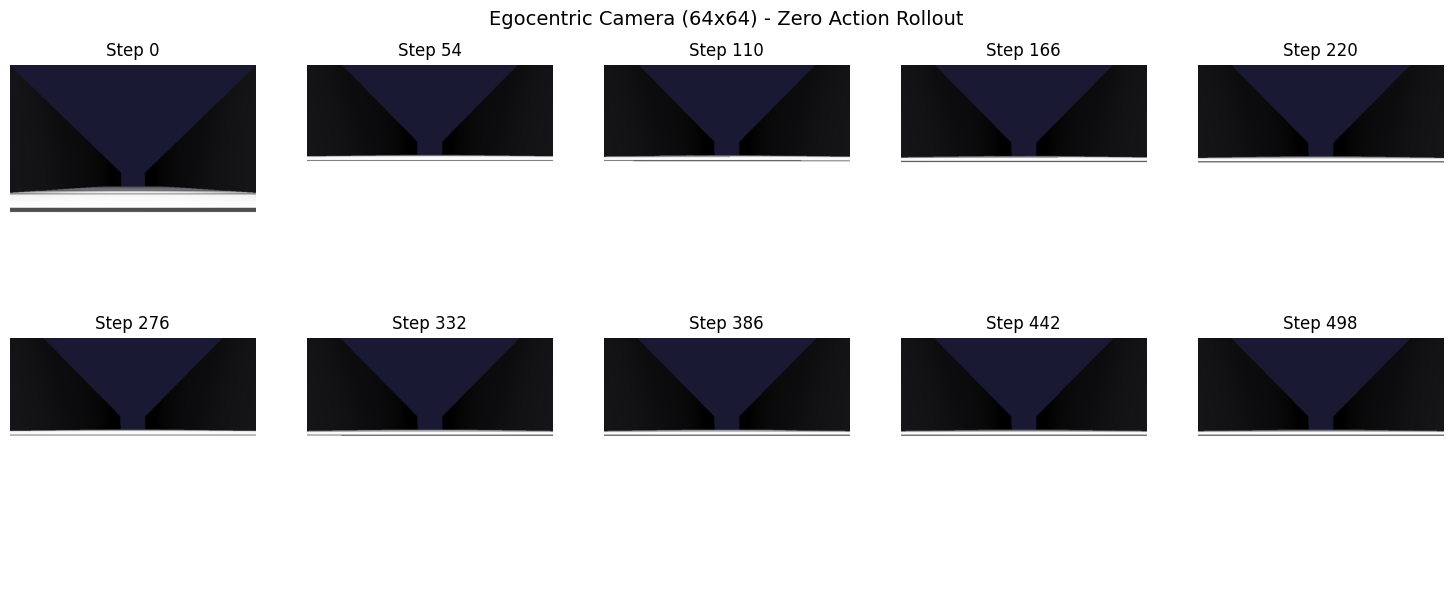

In [10]:
# Show sample vision frames
sample_indices = np.linspace(0, len(vision_frames) - 1, 10, dtype=int)
fig, axes = plt.subplots(2, 5, figsize=(15, 6))
for ax, idx in zip(axes.flat, sample_indices):
    ax.imshow(vision_frames[idx])
    ax.set_title(f"Step {idx * render_every}")
    ax.axis("off")
plt.suptitle("Egocentric Camera (64x64) - Zero Action Rollout", fontsize=14)
plt.tight_layout()
plt.show()

Rodent geom count: 100 / 113 total


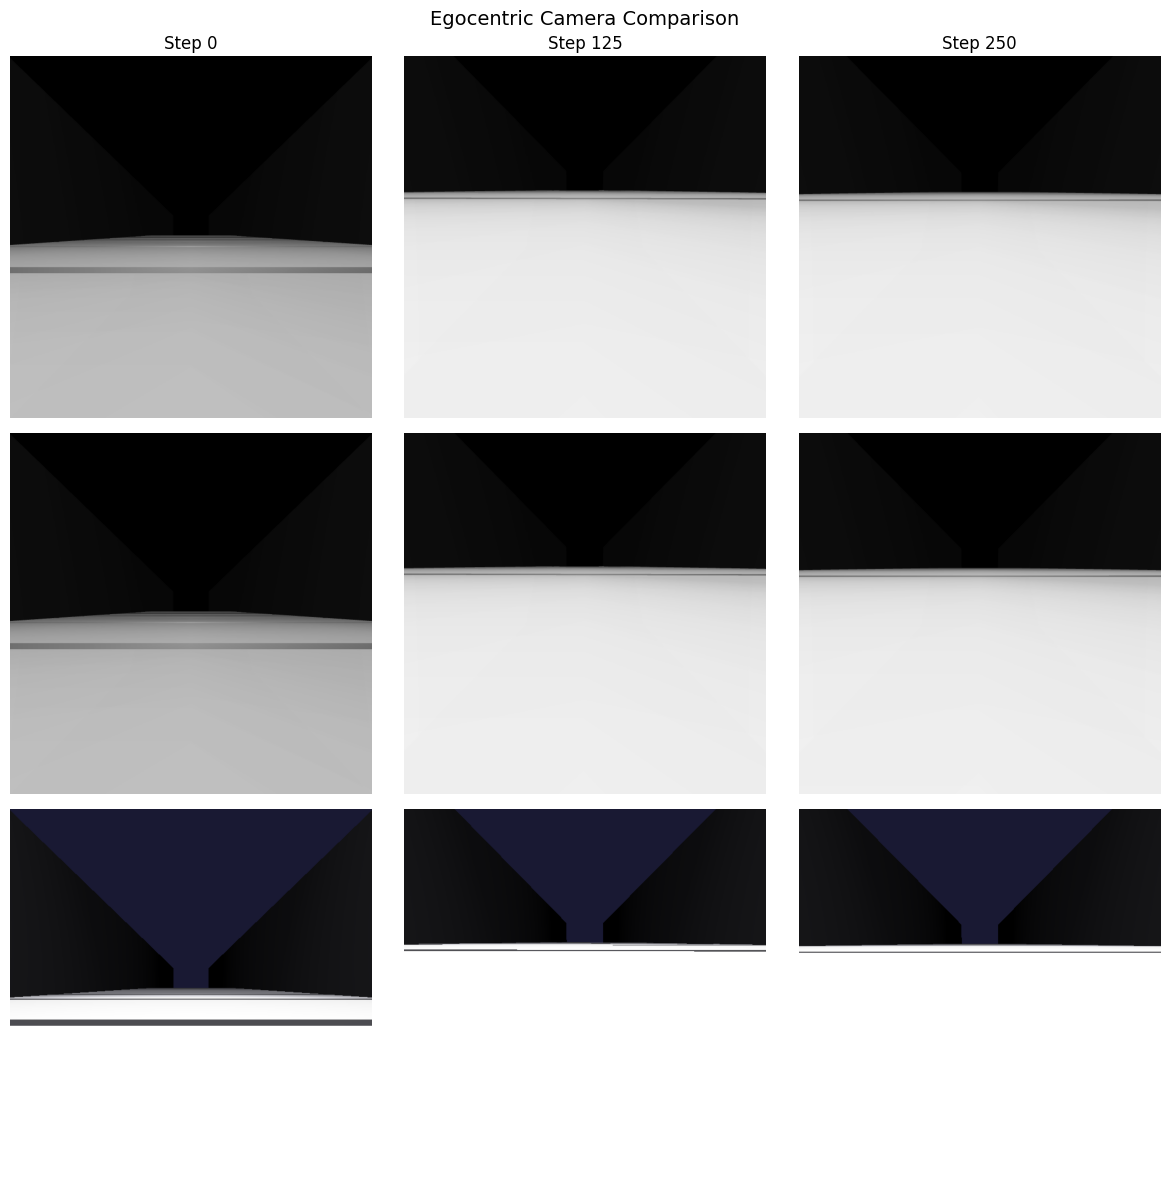

In [11]:
# Compare: MuJoCo software renderer vs Warp (with body hidden)
# Also hide body geoms in MuJoCo renderer by temporarily moving them to group 4
mj_data_cmp = mujoco.MjData(mj_model)
renderer_cmp = mujoco.Renderer(mj_model, height=640, width=640)

# Identify rodent body geom indices
rodent_body_ids = {
    i for i in range(mj_model.nbody) if mj_model.body(i).name.endswith("-rodent")
}
rodent_geom_ids = np.array(
    [i for i in range(mj_model.ngeom) if mj_model.geom_bodyid[i] in rodent_body_ids]
)
print(f"Rodent geom count: {len(rodent_geom_ids)} / {mj_model.ngeom} total")

compare_indices = [0, len(rollout_states) // 4, len(rollout_states) // 2]
fig, axes = plt.subplots(
    3, len(compare_indices), figsize=(4 * len(compare_indices), 12)
)

for col, idx in enumerate(compare_indices):
    state = rollout_states[idx]
    mj_data_cmp.qpos = np.array(state.data.qpos)
    mujoco.mj_forward(mj_model, mj_data_cmp)

    # Row 0: MuJoCo with body visible
    renderer_cmp.update_scene(mj_data_cmp, camera="egocentric-rodent")
    axes[0, col].imshow(renderer_cmp.render().copy())
    axes[0, col].set_title(f"Step {idx}")
    axes[0, col].axis("off")

    # Row 1: MuJoCo with body hidden (move rodent geoms to group 4)
    saved_groups = mj_model.geom_group[rodent_geom_ids].copy()
    mj_model.geom_group[rodent_geom_ids] = 4  # group 4 is hidden by default
    renderer_cmp.update_scene(mj_data_cmp, camera="egocentric-rodent")
    axes[1, col].imshow(renderer_cmp.render().copy())
    axes[1, col].axis("off")
    mj_model.geom_group[rodent_geom_ids] = saved_groups  # restore

    # Row 2: Warp VisionRenderer (body already hidden via hide_self_geoms)
    vision_renderer.sync_state(state.data)
    warp_frame, _ = vision_renderer.render()
    axes[2, col].imshow(warp_frame[0])
    axes[2, col].axis("off")

axes[0, 0].set_ylabel("MuJoCo\n(body visible)", fontsize=11)
axes[1, 0].set_ylabel("MuJoCo\n(body hidden)", fontsize=11)
axes[2, 0].set_ylabel("Warp\n(body hidden)", fontsize=11)
plt.suptitle("Egocentric Camera Comparison", fontsize=14)
plt.tight_layout()
plt.show()

renderer_cmp.close()

In [ ]:
# Show vision as video (upscaled for visibility)
vision_upscaled = [
    np.kron(f, np.ones((1, 1, 1))).astype(np.uint8) for f in vision_frames
]
media.show_video(
    vision_upscaled,
    fps=fps // render_every,
    title="Egocentric Vision (64x64, upscaled" " 4x)",
)

## 5. Concatenated Video: Scene + Vision Overlay

The egocentric vision output is overlaid on the upper-left corner of the main scene render,
inspired by [vnl-ray/utils.py](https://github.com/talmolab/vnl-ray/blob/71dfc1055ec51755d32445f8bdd4413750b346a9/vnl_ray/utils.py#L15).

In [ ]:
def overlay_vision_on_frame(scene_frame, vision_frame, scale=3, padding=8, border=2):
    """Overlay a small vision frame on the upper-left corner of a scene frame.

    Args:
        scene_frame: (H, W, 3) uint8 main camera frame.
        vision_frame: (h, w, 3) uint8 egocentric vision frame.
        scale: Upscale factor for the vision inset.
        padding: Pixel padding from the top-left corner.
        border: Border width around the vision inset.

    Returns:
        (H, W, 3) uint8 frame with vision overlay.
    """
    frame = scene_frame.copy()
    vh, vw = vision_frame.shape[:2]
    sh, sw = vh * scale, vw * scale

    # Upscale vision frame using nearest-neighbor
    vision_up = np.kron(vision_frame, np.ones((scale, scale, 1))).astype(np.uint8)

    # Draw border (dark background)
    y0 = padding
    x0 = padding
    frame[
        y0 - border : y0 + sh + border,
        x0 - border : x0 + sw + border,
    ] = 32  # dark gray border

    # Paste vision
    frame[y0 : y0 + sh, x0 : x0 + sw] = vision_up

    return frame

In [ ]:
# Build concatenated frames
n_concat = min(len(frames_profile), len(vision_frames))
concat_frames = []
for i in range(n_concat):
    concat_frames.append(
        overlay_vision_on_frame(frames_profile[i], vision_frames[i], scale=3)
    )

print(f"Concatenated {n_concat} frames")
media.show_video(
    concat_frames, fps=fps // render_every, title="Scene + Egocentric Vision Overlay"
)

In [ ]:
# Save all videos to disk
output_dir = os.path.join(os.getcwd(), "notebooks")

media.write_video(
    os.path.join(output_dir, "run_gap_close_profile.mp4"),
    frames_profile,
    fps=fps // render_every,
)
media.write_video(
    os.path.join(output_dir, "run_gap_egocentric_vision.mp4"),
    vision_upscaled,
    fps=fps // render_every,
)
media.write_video(
    os.path.join(output_dir, "run_gap_scene_with_vision.mp4"),
    concat_frames,
    fps=fps // render_every,
)

print(f"Saved videos to {output_dir}/")